#### Load the Dataset

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import seaborn as sns

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, log_loss, confusion_matrix, roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc

path_train = "/home/sarantis/Documents/Διπλωματική Εργασία/Diploma-Thesis/PV_dataset/datasets/train data.csv"  
train_data = pd.read_csv(path_train, delimiter=';')

path_test = "/home/sarantis/Documents/Διπλωματική Εργασία/Diploma-Thesis/PV_dataset/datasets/test data.csv"  
test_data = pd.read_csv(path_test, delimiter=';')

display(train_data.head(5))
display(test_data.head(5))

,I1,I2,I1MAX,I1MIN,I1VAR,I2MAX,I2MIN,I2VAR,I3,I4,...,Vdcmax1,Vdcmin1,Pdcmean1,IR,T,range 1,range 2,range 3,range 4,class
0,3.464132,3.464132,3.776515,3.433125,0.000054,3.776515,3.433125,0.000054,3.755050,3.755050,...,514.369415,509.002655,169.603373,660,22,0.343390,0.343390,1.332270e-14,5.773160e-15,1
1,2.244766,2.244766,2.611714,2.210978,0.000350,2.611714,2.210978,0.000350,2.572122,2.572122,...,521.970593,503.241431,116.954097,450,15,0.400736,0.400736,1.554310e-14,0.000000e+00,1
2,3.878360,3.878360,4.101282,3.854098,0.000010,4.101282,3.854098,0.000010,4.094577,4.094577,...,511.837039,509.378912,184.213307,720,24,0.247183,0.247183,2.131630e-14,7.105430e-15,1
3,2.816389,2.816389,3.285793,2.758149,0.000192,3.285793,2.758149,0.000192,3.247759,3.247759,...,518.028478,507.378348,147.283635,570,19,0.527644,0.527644,1.199040e-14,1.332270e-14,1
4,1.238798,1.238798,5.455667,0.141519,0.001153,5.455667,0.141519,0.001153,5.465640,5.465640,...,500.827418,500.127036,238.608844,960,32,5.314147,5.314147,2.442490e-14,2.042810e-14,1


,I1,I2,I1MAX,I1MIN,I1VAR,I2MAX,I2MIN,I2VAR,I3,I4,...,Vdcmax1,Vdcmin1,Pdcmean1,IR,T,range 1,range 2,range 3,range 4,class
0,2.79120,3.0740,3.0704,2.54180,0.060570,3.1119,3.00330,0.001416,3.0158,3.0158,...,506.76,483.08,132.930,526,26,0.52860,0.10860,-0.28280,0.0,2
1,3.45340,3.6386,3.6218,3.31490,0.018449,3.6889,3.56890,0.002442,3.5794,3.5794,...,500.68,489.94,157.050,627,31,0.30690,0.12000,-0.18520,0.0,2
2,1.95250,2.0837,2.3345,1.84450,0.012447,2.3366,2.03480,0.001690,2.0466,2.0466,...,492.02,475.91,88.824,357,33,0.49000,0.30180,-0.13120,0.0,2
3,2.40180,2.5785,2.5868,2.25420,0.021388,2.6087,2.51950,0.000998,2.5323,2.5323,...,500.54,476.94,110.530,442,29,0.33260,0.08920,-0.17670,0.0,2
4,0.85467,1.0284,2.3547,0.51656,0.211560,2.3567,0.86222,0.129860,1.0164,1.0164,...,509.73,476.00,46.718,148,11,1.83814,1.49448,-0.17373,0.0,2


#### Γραφική Απεικόνιση της Κλάσης 'Class' 

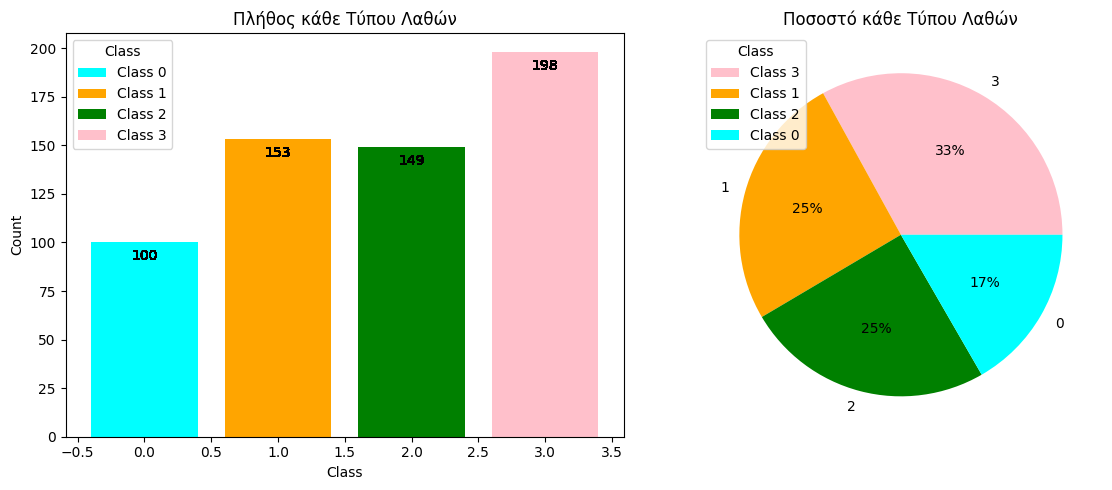

In [92]:
class_colors = {0: 'cyan', 1: 'orange', 2: 'green', 3: 'pink'}

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axs[0].set_title('Πλήθος κάθε Τύπου Λαθών')
for c, color in class_colors.items():
    subset = train_data[train_data['class'] == c]
    axs[0].bar(subset['class'], subset['class'].count(), color=color, label=f'Class {c}')

for p in axs[0].patches:
    height = p.get_height()
    axs[0].annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center', xytext=(0, -10), textcoords='offset points', fontsize=10, color='black')

axs[0].set_xlabel('Class')
axs[0].set_ylabel('Count')
axs[0].legend(labels=[f'Class {c}' for c in class_colors], title='Class')

axs[1].set_title('Ποσοστό κάθε Τύπου Λαθών')
value = train_data['class'].value_counts()
class_percentage = 100 * value / train_data['class'].shape[0]
labels = class_percentage.index.array
x = class_percentage.array

axs[1].pie(x, labels=labels, colors=[class_colors[c] for c in labels], autopct='%.0f%%')
axs[1].legend(labels=[f'Class {c}' for c in labels], title='Class', loc='upper left')

plt.tight_layout()
plt.show()

In [93]:
# Dataframe without class
X_train = train_data.drop('class', axis=1) 
X_test = test_data.drop('class', axis=1)
# Dataframe for Target Variable
y_train = train_data['class']  
y_test = test_data['class']

In [94]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Class distribution after oversampling:\n", y_train_resampled.value_counts())

Class distribution after oversampling:
 1    198
0    198
2    198
3    198
Name: class, dtype: int64


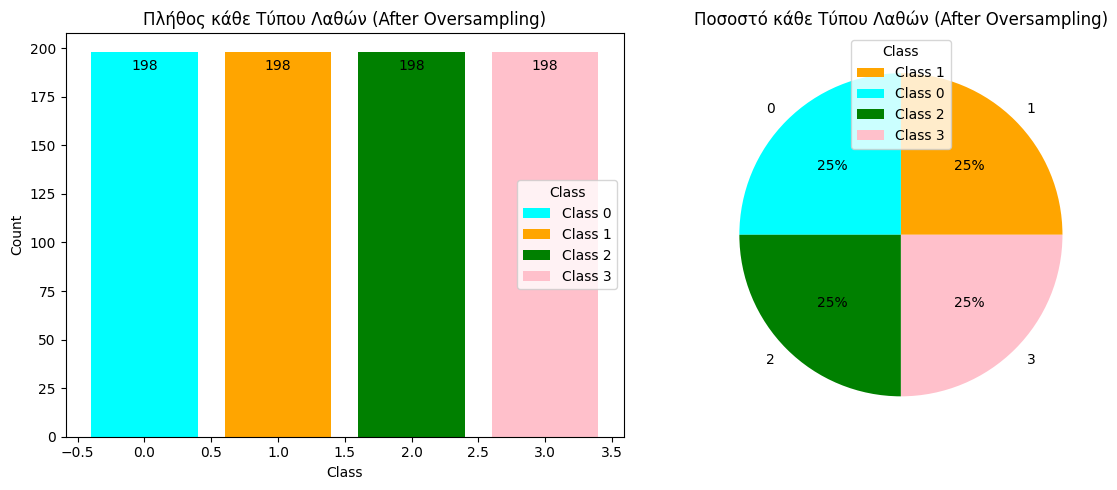

In [95]:
class_colors_resampled = {0: 'cyan', 1: 'orange', 2: 'green', 3: 'pink'}

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].set_title('Πλήθος κάθε Τύπου Λαθών (After Oversampling)')
for c, color in class_colors_resampled.items():
    subset = y_train_resampled[y_train_resampled == c]
    axs[0].bar(c, len(subset), color=color, label=f'Class {c}')

for p in axs[0].patches:
    height = p.get_height()
    axs[0].annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center', xytext=(0, -10), textcoords='offset points', fontsize=10, color='black')

axs[0].set_xlabel('Class')
axs[0].set_ylabel('Count')
axs[0].legend(labels=[f'Class {c}' for c in class_colors_resampled], title='Class', loc='center right')

axs[1].set_title('Ποσοστό κάθε Τύπου Λαθών (After Oversampling)')
value_resampled = pd.Series(y_train_resampled).value_counts()
class_percentage_resampled = 100 * value_resampled / len(y_train_resampled)
labels_resampled = class_percentage_resampled.index.array
x_resampled = class_percentage_resampled.array

axs[1].pie(x_resampled, labels=labels_resampled, colors=[class_colors_resampled[c] for c in labels_resampled], autopct='%.0f%%')
axs[1].legend(labels=[f'Class {c}' for c in labels_resampled], title='Class', loc='upper center')

plt.tight_layout()
plt.show()

#### Min-Max Scaling

In [96]:
scaler = MinMaxScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)
X_resampled_scaled = pd.DataFrame(scaler.fit_transform(X_train_resampled), columns=X_train_resampled.columns)

#### Random Forest Algorithm with Resampled Dataset

In [97]:
'''
param_grid = {
    'max_depth': [2, 3, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10, 20], 
    'min_samples_leaf': [5, 10, 20, 100, 200, 300],
    'n_estimators': [10, 25, 50, 100, 200, 300],
}

rf_smote = RandomForestClassifier(random_state=42)

# GridSearchCV 
grid_search = GridSearchCV(estimator=rf_smote, param_grid=param_grid, cv=5, scoring='accuracy')
 
# Fit
grid_search.fit(X_resampled_scaled, y_train_resampled)

# Best parameters & mean cross-validated score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f'Best Parameters: {best_params}')
print(f'Best Mean Cross-Validated Score: {best_score}')

rf_smote = RandomForestClassifier(random_state=42,
                                       max_depth=best_params['max_depth'],
                                       min_samples_split=best_params['min_samples_split'],
                                       min_samples_leaf=best_params['min_samples_leaf'],
                                       n_estimators=best_params['n_estimators'])

y_train_array1 = y_train_resampled.values.ravel()

# Fit the model
rf_smote.fit(X_resampled_scaled, y_train_array1)
'''

"\nparam_grid = {\n    'max_depth': [2, 3, 5, 10, 20, 30],\n    'min_samples_split': [2, 5, 10, 20], \n    'min_samples_leaf': [5, 10, 20, 100, 200, 300],\n    'n_estimators': [10, 25, 50, 100, 200, 300],\n}\n\nrf_smote = RandomForestClassifier(random_state=42)\n\n# GridSearchCV \ngrid_search = GridSearchCV(estimator=rf_smote, param_grid=param_grid, cv=5, scoring='accuracy')\n \n# Fit\ngrid_search.fit(X_resampled_scaled, y_train_resampled)\n\n# Best parameters & mean cross-validated score\nbest_params = grid_search.best_params_\nbest_score = grid_search.best_score_\n\nprint(f'Best Parameters: {best_params}')\nprint(f'Best Mean Cross-Validated Score: {best_score}')\n\nrf_smote = RandomForestClassifier(random_state=42,\n                                       max_depth=best_params['max_depth'],\n                                       min_samples_split=best_params['min_samples_split'],\n                                       min_samples_leaf=best_params['min_samples_leaf'],\n              

In [98]:
rf_smote = RandomForestClassifier(
    max_depth=2,
    min_samples_leaf=20,
    n_estimators=300,
    random_state=42
)

y_train_array1 = y_train_resampled.values.ravel()

# Fit the model
rf_smote.fit(X_resampled_scaled, y_train_array1)

RandomForestClassifier(max_depth=2, min_samples_leaf=20, n_estimators=300,
                       random_state=42)

#### Evaluation on Training Data

In [99]:
y_train_smote_pred_proba = rf_smote.predict_proba(X_resampled_scaled)

# Precision
precision_train_smote = precision_score(y_train_resampled, rf_smote.predict(X_resampled_scaled), average='weighted')

# Recall
recall_train_smote = recall_score(y_train_resampled, rf_smote.predict(X_resampled_scaled), average='weighted')

# F1-Score
f1_train_smote = f1_score(y_train_resampled, rf_smote.predict(X_resampled_scaled), average='weighted')

# Classification Accuracy
accuracy_train_smote = accuracy_score(y_train_resampled, rf_smote.predict(X_resampled_scaled))

# Log Loss
log_loss_value_train_smote = log_loss(y_train_resampled, y_train_smote_pred_proba)

# Confusion Matrix
conf_matrix_train_smote = confusion_matrix(y_train_resampled, rf_smote.predict(X_resampled_scaled))

# AROC Curve
roc_auc_train_smote = roc_auc_score(y_train_resampled, y_train_smote_pred_proba, multi_class='ovr', labels=rf_smote.classes_)

# Evaluation Metrics
print(f'Training Confusion Matrix (SMOTE):\n{conf_matrix_train_smote}')
print()
print(f'Training Area Under the ROC Curve (AROC) (SMOTE): {roc_auc_train_smote}')
print(f'Training Accuracy (SMOTE): {accuracy_train_smote}')
print(f'Training F1-Score (SMOTE): {f1_train_smote}')
print(f'Training Precision (SMOTE): {precision_train_smote}')
print(f'Training Recall (SMOTE): {recall_train_smote}')
print(f'Training Log Loss (SMOTE): {log_loss_value_train_smote}')

Training Confusion Matrix (SMOTE):
[[198   0   0   0]
 [  0 198   0   0]
 [  0   0 198   0]
 [  0   0   0 198]]

Training Area Under the ROC Curve (AROC) (SMOTE): 1.0
Training Accuracy (SMOTE): 1.0
Training F1-Score (SMOTE): 1.0
Training Precision (SMOTE): 1.0
Training Recall (SMOTE): 1.0
Training Log Loss (SMOTE): 0.6793269774551705


#### Evaluation on Test Data

In [100]:
y_test_pred_smote = rf_smote.predict(X_test_scaled)
#y_test_proba = rf_smote.predict_proba(X_test_scaled)[:, 1]  
y_test_smote_pred_proba = rf_smote.predict_proba(X_test_scaled)

# Precision
precision_test_smote = precision_score(y_test, y_test_pred_smote, average='weighted')

# Recall
recall_test_smote = recall_score(y_test, y_test_pred_smote, average='weighted')

# F1-Score
f1_test_smote = f1_score(y_test, y_test_pred_smote, average='weighted')

# Classification Accuracy
accuracy_test_smote = accuracy_score(y_test, y_test_pred_smote)

# Log Loss
log_loss_value_test_smote = log_loss(y_test, y_test_smote_pred_proba, labels=rf_smote.classes_)

# Confusion Matrix
conf_matrix_test_smote = confusion_matrix(y_test, y_test_pred_smote)

# AROC Curve
roc_auc_test_smote = roc_auc_score(y_test, y_test_smote_pred_proba, multi_class='ovr')

# Evaluation Metrics
print(f'Test Confusion Matrix (SMOTE):\n{conf_matrix_test_smote}')
print()
print(f'Test Area Under the ROC Curve (AROC) (SMOTE): {roc_auc_test_smote}')
print(f'Test Accuracy (SMOTE): {accuracy_test_smote}')
print(f'Test F1-Score (SMOTE): {f1_test_smote}')
print(f'Test Precision (SMOTE): {precision_test_smote}')
print(f'Test Recall (SMOTE): {recall_test_smote}')
print(f'Test Log Loss (SMOTE): {log_loss_value_test_smote}')


Test Confusion Matrix (SMOTE):
[[25  0  0  0]
 [ 5 20  0  0]
 [ 0  7 18  0]
 [ 0  0  0 25]]

Test Area Under the ROC Curve (AROC) (SMOTE): 0.9863999999999999
Test Accuracy (SMOTE): 0.88
Test F1-Score (SMOTE): 0.878882745161815
Test Precision (SMOTE): 0.8935185185185185
Test Recall (SMOTE): 0.88
Test Log Loss (SMOTE): 0.7868465402196532


### Class Weights in Minority Classes

In [101]:
'''
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))

rf_classifier = RandomForestClassifier(random_state=42,
                                       class_weight=class_weight_dict,
                                       max_depth=best_params['max_depth'],
                                       min_samples_split=best_params['min_samples_split'],
                                       min_samples_leaf=best_params['min_samples_leaf'],
                                       n_estimators=best_params['n_estimators'])

y_train_array2 = y_train.values.ravel()

# Fit the model
rf_classifier.fit(X_train_scaled, y_train_array2)
'''

"\nfrom sklearn.utils.class_weight import compute_class_weight\n\nclass_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)\nclass_weight_dict = dict(zip(np.unique(y_train), class_weights))\n\nrf_classifier = RandomForestClassifier(random_state=42,\n                                       class_weight=class_weight_dict,\n                                       max_depth=best_params['max_depth'],\n                                       min_samples_split=best_params['min_samples_split'],\n                                       min_samples_leaf=best_params['min_samples_leaf'],\n                                       n_estimators=best_params['n_estimators'])\n\ny_train_array2 = y_train.values.ravel()\n\n# Fit the model\nrf_classifier.fit(X_train_scaled, y_train_array2)\n"

In [102]:
max_depth = 2
min_samples_leaf = 20
n_estimators = 300
random_state = 42
class_weight = {0: 1.5, 1: 0.9803921568627451, 2: 1.0067114093959733, 3: 0.7575757575757576}

rf_classifier = RandomForestClassifier(
    max_depth=max_depth,
    min_samples_leaf=min_samples_leaf,
    n_estimators=n_estimators,
    random_state=random_state,
    class_weight=class_weight
)

y_train_array2 = y_train.values.ravel()

# Fit the model
rf_classifier.fit(X_train_scaled, y_train_array2)

RandomForestClassifier(class_weight={0: 1.5, 1: 0.9803921568627451,
                                     2: 1.0067114093959733,
                                     3: 0.7575757575757576},
                       max_depth=2, min_samples_leaf=20, n_estimators=300,
                       random_state=42)

#### Evaluation on Training Data

In [103]:
y_train_minority_pred_proba = rf_classifier.predict_proba(X_train_scaled)

# Precision
precision_train_minority = precision_score(y_train, rf_classifier.predict(X_train_scaled), average='weighted')

# Recall
recall_train_minority = recall_score(y_train, rf_classifier.predict(X_train_scaled), average='weighted')

# F1-Score
f1_train_minority = f1_score(y_train, rf_classifier.predict(X_train_scaled), average='weighted')

# Classification Accuracy
accuracy_train_minority = accuracy_score(y_train, rf_classifier.predict(X_train_scaled))

# Log Loss
log_loss_value_train_minority = log_loss(y_train, y_train_minority_pred_proba)

# Confusion Matrix
conf_matrix_train_minority = confusion_matrix(y_train, rf_classifier.predict(X_train_scaled))

# AROC Curve
roc_auc_train_minority = roc_auc_score(y_train, y_train_minority_pred_proba, multi_class='ovr')

# Evaluation Metrics
print(f'Training Confusion Matrix (Minority):\n{conf_matrix_train_minority}')
print()
print(f'Training Area Under the ROC Curve (AROC) (Minority): {roc_auc_train_minority}')
print(f'Training Accuracy (Minority): {accuracy_train_minority}')
print(f'Training F1-Score (Minority): {f1_train_minority}')
print(f'Training Precision (Minority): {precision_train_minority}')
print(f'Training Recall (Minority): {recall_train_minority}')
print(f'Training Log Loss (Minority): {log_loss_value_train_minority}')

Training Confusion Matrix (Minority):
[[100   0   0   0]
 [  0 153   0   0]
 [  0   0 149   0]
 [  0   0   0 198]]

Training Area Under the ROC Curve (AROC) (Minority): 1.0
Training Accuracy (Minority): 1.0
Training F1-Score (Minority): 1.0
Training Precision (Minority): 1.0
Training Recall (Minority): 1.0
Training Log Loss (Minority): 0.688643317743676


#### Evaluation on Test Data

In [104]:
y_test_pred_minority = rf_classifier.predict(X_test_scaled)
#y_test_proba = rf_classifier.predict_proba(X_test_scaled)[:, 1]  
y_test_minority_pred_proba = rf_classifier.predict_proba(X_test_scaled)

# Precision
precision_test_minority = precision_score(y_test, y_test_pred_minority, average='weighted')

# Recall
recall_test_minority = recall_score(y_test, y_test_pred_minority, average='weighted')

# F1-Score
f1_test_minority = f1_score(y_test, y_test_pred_minority, average='weighted')

# Classification Accuracy
accuracy_test_minority = accuracy_score(y_test, y_test_pred_minority)

# Log Loss
log_loss_value_test_minority = log_loss(y_test, y_test_minority_pred_proba)

# Confusion Matrix
conf_matrix_test_minority = confusion_matrix(y_test, y_test_pred_minority)

# AROC Curve
roc_auc_test_minority = roc_auc_score(y_test, y_test_minority_pred_proba, multi_class='ovr')

# Evaluation Metrics
print(f'Test Confusion Matrix (Minority):\n{conf_matrix_test_minority}')
print()
print(f'Test Area Under the ROC Curve (AROC) (Minority): {roc_auc_test_minority}')
print(f'Test Accuracy (Minority): {accuracy_test_minority}')
print(f'Test F1-Score (Minority): {f1_test_minority}')
print(f'Test Precision (Minority): {precision_test_minority}')
print(f'Test Recall (Minority): {recall_test_minority}')
print(f'Test Log Loss (Minority): {log_loss_value_test_minority}')


Test Confusion Matrix (Minority):
[[25  0  0  0]
 [ 5 20  0  0]
 [ 0 11 14  0]
 [ 0  0  0 25]]

Test Area Under the ROC Curve (AROC) (Minority): 0.9852
Test Accuracy (Minority): 0.84
Test F1-Score (Minority): 0.8353313353313354
Test Precision (Minority): 0.8696236559139785
Test Recall (Minority): 0.84
Test Log Loss (Minority): 0.8058221357202308


### Plot the Results

##### Load Values from Notebook rf_smote.ipynb

In [105]:
%store -r precision
%store -r recall
%store -r f1
%store -r accuracy
%store -r log_loss_value_test
%store -r conf_matrix
%store -r roc_auc

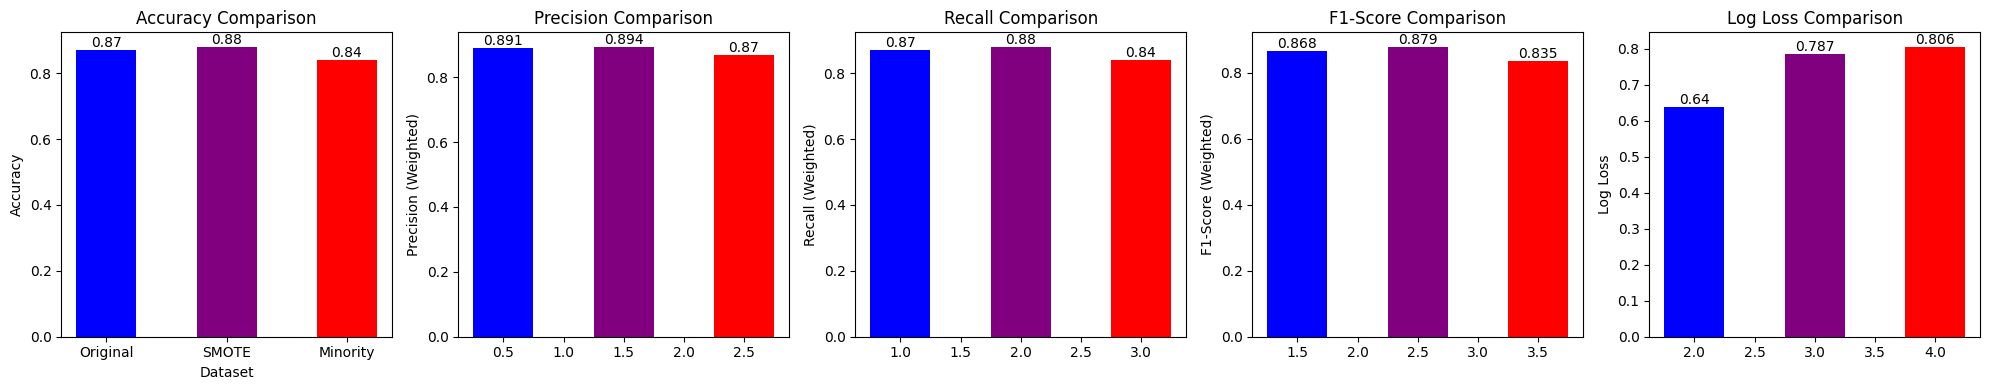

In [106]:
import matplotlib.pyplot as plt

# Sample data for Accuracy
categories_accuracy = ['Original', 'SMOTE', 'Minority']
accuracy_values = [accuracy, accuracy_test_smote, accuracy_test_minority]

# Plotting Accuracy with thinner bars
bar_width = 0.5
bar_positions_accuracy = range(len(categories_accuracy))

fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 4))

# Plot Accuracy
bars_accuracy = axes[0].bar(bar_positions_accuracy, accuracy_values, width=bar_width, color=['blue', 'purple', 'red'])

# Adding text annotations inside the bars for Accuracy
for bar, accuracy_value in zip(bars_accuracy, accuracy_values):
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width() / 2, yval, round(accuracy_value, 3), ha='center', va='bottom', fontsize=10)

# Customize the plot for Accuracy
axes[0].set_title('Accuracy Comparison')
axes[0].set_xlabel('Dataset')
axes[0].set_ylabel('Accuracy')
axes[0].set_xticks(bar_positions_accuracy)
axes[0].set_xticklabels(categories_accuracy)


# Sample data for Precision
categories_precision = ['Original', 'SMOTE', 'Minority']
precision_values = [precision, precision_test_smote, precision_test_minority]

# Plotting Precision with thinner bars
bar_positions_precision = [pos + bar_width for pos in bar_positions_accuracy]

# Plot Precision
bars_precision = axes[1].bar(bar_positions_precision, precision_values, width=bar_width, color=['blue', 'purple', 'red'])

# Adding text annotations inside the bars for Precision
for bar, precision_value in zip(bars_precision, precision_values):
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width() / 2, yval, round(precision_value, 3), ha='center', va='bottom', fontsize=10)

# Customize the plot for Precision
axes[1].set_title('Precision Comparison')
axes[1].set_ylabel('Precision (Weighted)')


# Sample data for Recall
recall_values = [recall, recall_test_smote, recall_test_minority]

# Plotting Recall with thinner bars
bar_positions_recall = [pos + 2 * bar_width for pos in bar_positions_accuracy]

# Plot Recall
bars_recall = axes[2].bar(bar_positions_recall, recall_values, width=bar_width, color=['blue', 'purple', 'red'])

# Adding text annotations inside the bars for Recall
for bar, recall_value in zip(bars_recall, recall_values):
    yval = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width() / 2, yval, round(recall_value, 3), ha='center', va='bottom', fontsize=10)

# Customize the plot for Recall
axes[2].set_title('Recall Comparison')
axes[2].set_ylabel('Recall (Weighted)')


# Sample data for F1 Score
f1_values = [f1, f1_test_smote, f1_test_minority]

# Plotting F1 Score with thinner bars
bar_positions_f1 = [pos + 3 * bar_width for pos in bar_positions_accuracy]

# Plot F1 Score
bars_f1 = axes[3].bar(bar_positions_f1, f1_values, width=bar_width, color=['blue', 'purple', 'red'])

# Adding text annotations inside the bars for F1 Score
for bar, f1_value in zip(bars_f1, f1_values):
    yval = bar.get_height()
    axes[3].text(bar.get_x() + bar.get_width() / 2, yval, round(f1_value, 3), ha='center', va='bottom', fontsize=10)

# Customize the plot for F1 Score
axes[3].set_title('F1-Score Comparison')
axes[3].set_ylabel('F1-Score (Weighted)')


# Sample data for Log Loss
log_loss_values = [log_loss_value_test, log_loss_value_test_smote, log_loss_value_test_minority]

# Plotting Log Loss with thinner bars
bar_positions_log_loss = [pos + 4 * bar_width for pos in bar_positions_accuracy]

# Plot Log Loss
bars_log_loss = axes[4].bar(bar_positions_log_loss, log_loss_values, width=bar_width, color=['blue', 'purple', 'red'])

# Adding text annotations inside the bars for Log Loss
for bar, log_loss_value in zip(bars_log_loss, log_loss_values):
    yval = bar.get_height()
    axes[4].text(bar.get_x() + bar.get_width() / 2, yval, round(log_loss_value, 3), ha='center', va='bottom', fontsize=10)

# Customize the plot for Log Loss
axes[4].set_title('Log Loss Comparison')
axes[4].set_ylabel('Log Loss')


# Show the plots
plt.tight_layout()
plt.show()


### ROC Curves

In [107]:
# Load the stored model
%store -r random_forest

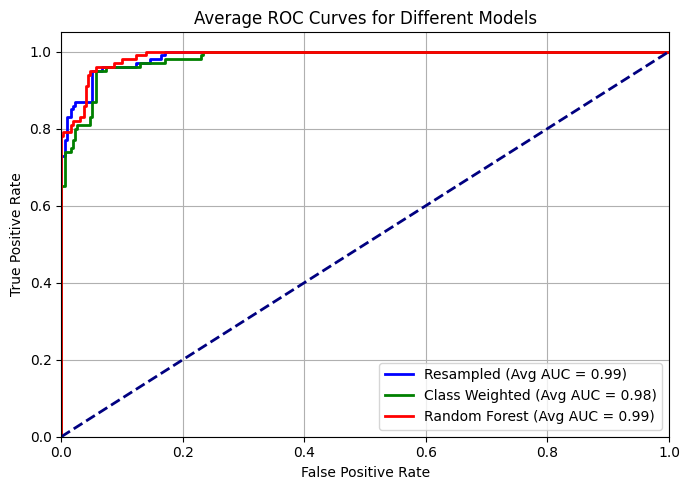

In [108]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

model_names = ['Resampled', 'Class Weighted', 'Random Forest']
models_list = [rf_smote, rf_classifier, random_forest]
datasets = [X_test_scaled, X_test_scaled, X_test_scaled]
labels = [y_test, y_test, y_test]
model_colors = ['blue', 'green', 'red']

for model_name, model, dataset, label, color in zip(model_names, models_list, datasets, labels, model_colors):
    y_pred_proba = model.predict_proba(dataset)
    
    label_binarizer = LabelBinarizer()
    y_binary = label_binarizer.fit_transform(label)
    
    fpr, tpr, _ = roc_curve(y_binary.ravel(), y_pred_proba.ravel())
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{model_name} (Avg AUC = {roc_auc:.2f})', linestyle='-', linewidth=2, color=color)

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Average ROC Curves for Different Models')
plt.legend(loc='lower right')

plt.grid(True)
plt.tight_layout()
plt.show()